# Policy Position Curves: Curriculum vs Reverse Curriculum (Final)

This notebook plots **dataset-level policy-position curves** for `curriculum` and `reverse_curriculum`
from `random_vs_uncertainty_final` using **hierarchical bootstrap**.

For each position index `i`, the y-value is built from:
1. per-permutation metric at position `i`,
2. averaged within subset over permutations,
3. hierarchical bootstrap over subsets within task, then across tasks.


In [10]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

REPO_ROOT = Path('/data/ddmg/mvseg-ordering').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.analysis.planb_utils import load_planb_summaries
from experiments.analysis.hierarchical_ci import (
    compute_subset_scores,
    hierarchical_bootstrap_task_estimates,
    dataset_bootstrap_stats,
)


In [11]:
# -----------------------------
# Config
# -----------------------------
PROCEDURE = 'random_vs_uncertainty_final'
ABLATION = 'pretrained_baseline5p'
METRIC = 'initial_dice'  # e.g. initial_dice, final_dice, iterations_used

METRIC_DISPLAY = {
    'initial_dice': 'Initial Dice Score',
    'final_dice': 'Final Dice Score',
    'iterations_used': 'Interactions Used',
}

POLICIES = ['curriculum', 'reverse_curriculum', 'random']
POLICY_LABELS = {
    'curriculum': 'Hard → Easy',
    'reverse_curriculum': 'Easy → Hard',
    'random': 'Random',
}

N_BOOT = 2000
SEED = 23
ALPHA = 0.05

N_COLS = 3
Y_LIM = None  # e.g. (0.4, 0.9)

SAVE_FIG = False
FIG_DIR = REPO_ROOT / 'figures' / 'policy_position_curves_final'

In [12]:
def summarize_dataset_position_curves(
    dataset_df: pd.DataFrame,
    *,
    metric: str,
    policies: list[str],
    n_boot: int,
    seed: int,
    alpha: float,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    image_indices = sorted(int(x) for x in dataset_df['image_index'].dropna().unique())
    for policy_name in policies:
        policy_df = dataset_df[dataset_df['policy_name'].astype(str) == str(policy_name)].copy()
        if policy_df.empty:
            continue

        for image_idx in image_indices:
            at_pos = policy_df[policy_df['image_index'] == image_idx].copy()
            if at_pos.empty:
                continue

            # Per-subset mean at this position (mean across permutations).
            subset_scores = compute_subset_scores(
                at_pos,
                metric,
                task_col='task_id',
                policy_col='policy_name',
            )
            if subset_scores.empty:
                continue

            subset_scores_by_task = {
                str(task_id): grp['subset_mean'].to_numpy(dtype=float)
                for task_id, grp in subset_scores.groupby('task_id')
            }
            subset_scores_by_task = {
                k: v for k, v in subset_scores_by_task.items() if v.size > 0
            }
            if not subset_scores_by_task:
                continue

            task_boot = hierarchical_bootstrap_task_estimates(
                subset_scores_by_task,
                n_boot=n_boot,
                seed=seed,
            )
            _, mean, ci_lo, ci_hi = dataset_bootstrap_stats(task_boot, alpha=alpha)

            rows.append(
                {
                    'policy_name': str(policy_name),
                    'policy_label': POLICY_LABELS.get(str(policy_name), str(policy_name)),
                    'image_index': int(image_idx),
                    'mean': float(mean),
                    'ci_lo': float(ci_lo),
                    'ci_hi': float(ci_hi),
                    'n_tasks': int(len(subset_scores_by_task)),
                    'n_subsets': int(subset_scores.shape[0]),
                }
            )

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    out = out.sort_values(['policy_name', 'image_index']).reset_index(drop=True)
    return out


In [13]:
raw = load_planb_summaries(
    repo_root=REPO_ROOT,
    procedure=PROCEDURE,
    ablation=ABLATION,
    dataset=None,
    filename='subset_support_images_summary.csv',
    allow_root_fallback=True,
)

if METRIC not in raw.columns:
    raise ValueError(f'METRIC={METRIC!r} not found. Available columns include: {sorted(raw.columns)}')

raw = raw[raw['policy_name'].astype(str).isin(POLICIES)].copy()
if raw.empty:
    raise ValueError(f'No rows found for policies={POLICIES} in procedure={PROCEDURE}, ablation={ABLATION}.')

# Quick check for permutation count at each (task,subset,policy,image_index).
perm_counts = (
    raw.groupby(['family', 'task_id', 'subset_index', 'policy_name', 'image_index'])['permutation_index']
    .nunique()
)
print(
    f'Permutation count per (family,task,subset,policy,image_index): '
    f'min={int(perm_counts.min())}, median={float(perm_counts.median()):.1f}, max={int(perm_counts.max())}'
)

family_summaries: dict[str, pd.DataFrame] = {}
for family, fam_df in raw.groupby('family'):
    summary = summarize_dataset_position_curves(
        fam_df,
        metric=METRIC,
        policies=POLICIES,
        n_boot=N_BOOT,
        seed=SEED,
        alpha=ALPHA,
    )
    if summary.empty:
        continue
    family_summaries[str(family)] = summary

if not family_summaries:
    raise ValueError('No dataset summaries were produced.')

print('Datasets:', sorted(family_summaries.keys()))
for fam, df in family_summaries.items():
    print(f'  {fam}: rows={len(df):,}, tasks={int(df["n_tasks"].max())}')


Permutation count per (family,task,subset,policy,image_index): min=10, median=10.0, max=100
Datasets: ['ACDC', 'BTCV', 'BUID', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']
  ACDC: rows=30, tasks=6
  BTCV: rows=30, tasks=20
  BUID: rows=30, tasks=4
  HipXRay: rows=30, tasks=4
  PanDental: rows=30, tasks=4
  SCD: rows=30, tasks=4
  SCR: rows=30, tasks=20
  T1mix: rows=30, tasks=39
  TotalSegmentator: rows=20, tasks=44
  WBC: rows=30, tasks=8


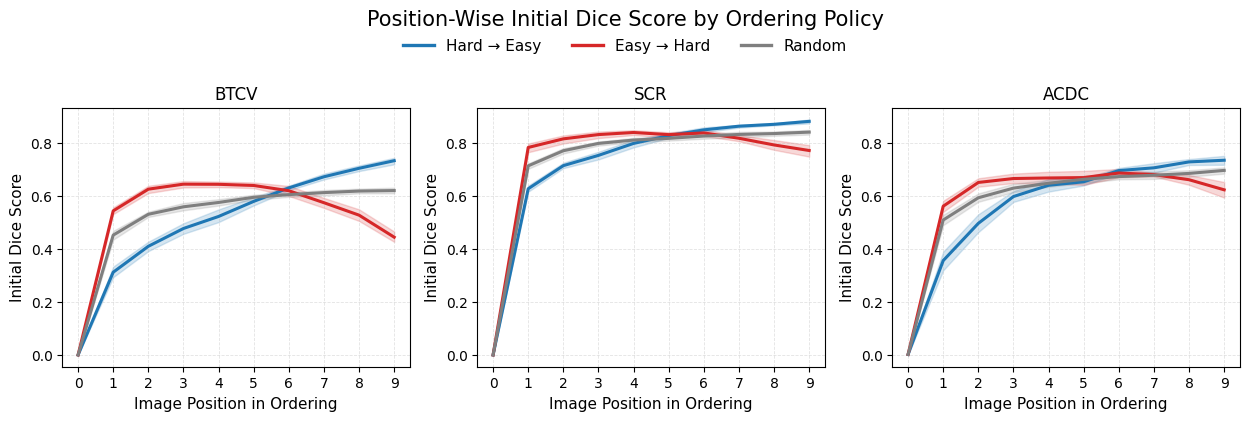

In [25]:
families = sorted(family_summaries.keys())
n_families = len(families)
n_cols = 3
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.2 * n_rows), squeeze=False, sharey=True)
axes_flat = axes.ravel()

color_map = {
    'curriculum': '#1f77b4',          # blue
    'reverse_curriculum': '#d62728',  # red
    'random': '#7f7f7f',              # gray
}

metric_label = METRIC_DISPLAY.get(METRIC, METRIC.replace('_', ' ').title())

for i, family in enumerate(['BTCV', 'SCR', 'ACDC']):
    ax = axes_flat[i]
    summary = family_summaries[family]

    for policy_name in POLICIES:
        sub = summary[summary['policy_name'] == policy_name].sort_values('image_index')
        if sub.empty:
            continue
        x = sub['image_index'].to_numpy(dtype=float)
        y = sub['mean'].to_numpy(dtype=float)
        lo = sub['ci_lo'].to_numpy(dtype=float)
        hi = sub['ci_hi'].to_numpy(dtype=float)

        color = color_map.get(policy_name, None)
        label = POLICY_LABELS.get(policy_name, policy_name)
        
        ax.plot(x, y, color=color, linewidth=2.2, label=label)
        ax.fill_between(x, lo, hi, color=color, alpha=0.18)

    ax.set_title(f"{family}", fontsize=12)
    ax.set_xlabel('Image Position in Ordering', fontsize=11)
    ax.tick_params(axis='y', labelleft=True)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.35)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if Y_LIM is not None:
        ax.set_ylim(*Y_LIM)

# Hide unused panels.
for j in range(n_families, len(axes_flat)):
    axes_flat[j].axis('off')

# Figure-level legend placed below title to avoid overlap.
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=color_map[p], linewidth=2.4, label=POLICY_LABELS.get(p, p))
    for p in POLICIES
    if p in color_map
]
if legend_handles:
    fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.955),
        ncol=max(1, len(legend_handles)),
        frameon=False,
        fontsize=11,
    )

fig.suptitle(
    f'Position-Wise {metric_label} by Ordering Policy',
    fontsize=15, y=0.992,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    out_path = FIG_DIR / f'policy_position_curves_{METRIC}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    print(f'saved: {out_path}')

plt.show()